# BigGAN + MidJourney: Cat 4 Classes, IQA + CLIP + XGBoost / MLP

Notebook ini menggabungkan dua keluarga fitur: **NR-IQA** (`PIQE`, `BRISQUE`, `NIQE`) dan **CLIP image embedding**. Setup data tetap sama seperti notebook `08`?`11`.


In [1]:
from pathlib import Path
import hashlib
import json
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import pyiqa
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from transformers import CLIPModel, CLIPProcessor
from xgboost import XGBClassifier

PROJECT_ROOT = Path("..")
DATA_ROOTS = {
    "BigGAN": PROJECT_ROOT / "data" / "raw" / "genimage" / "BigGAN" / "train",
    "MidJourney": PROJECT_ROOT / "data" / "raw" / "genimage" / "MidJourney" / "train",
}
IMAGENET_MAP = PROJECT_ROOT / "data" / "imagenet_class_index.json"
COMMON_CLASSES = {
    "281": "n02123045",  # tabby
    "283": "n02123394",  # Persian_cat
    "284": "n02123597",  # Siamese_cat
    "285": "n02124075",  # Egyptian_cat
}
COMMON_WNIDS = set(COMMON_CLASSES.values())
CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
CLIP_OUT_DIM = 64

print("Data roots:")
for k, v in DATA_ROOTS.items():
    print(k, v.resolve())
print("Cat classes:", COMMON_CLASSES)
SUBSET_NAME = "biggan_midjourney_cat4_train"
MANIFEST_OUT = PROJECT_ROOT / "data" / "genimage_manifest_biggan_midjourney_cat4_train.csv"
CLIP_OUT = PROJECT_ROOT / "artifacts" / "features_clip_biggan_midjourney_cat4_train.csv"
IQA_OUT = PROJECT_ROOT / "artifacts" / "features_iqa_biggan_midjourney_cat4_train.csv"
VECTOR_OUT = PROJECT_ROOT / "artifacts" / "feature_vector_biggan_midjourney_cat4_iqa_clip.csv"
METRICS_OUT = PROJECT_ROOT / "artifacts" / "results_classification_biggan_midjourney_cat4_iqa_clip.csv"
PRED_OUT = PROJECT_ROOT / "artifacts" / "predictions_classification_biggan_midjourney_cat4_iqa_clip.csv"


/home/nanda/miniconda3/envs/ai/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data roots:
BigGAN /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/data/raw/genimage/BigGAN/train
MidJourney /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/data/raw/genimage/MidJourney/train
Cat classes: {'281': 'n02123045', '283': 'n02123394', '284': 'n02123597', '285': 'n02124075'}


## 1. Audit data per generator

In [2]:
mapping = json.loads(IMAGENET_MAP.read_text())
idx_to_info = {int(k): tuple(v) for k, v in mapping.items()}
wnid_to_label = {v[0]: v[1] for v in mapping.values()}

def is_valid_image_file(path: Path) -> bool:
    if not path.is_file():
        return False
    if ":Zone.Identifier" in path.name:
        return False
    return path.suffix.lower() in {".png", ".jpg", ".jpeg", ".webp", ".bmp"}

audit_rows = []
for gen_name, data_root in DATA_ROOTS.items():
    ai_files = [p for p in (data_root / "ai").iterdir() if is_valid_image_file(p)]
    nature_files = [p for p in (data_root / "nature").iterdir() if is_valid_image_file(p)]

    ai_counts = Counter()
    nature_counts = Counter()

    for p in ai_files:
        m = re.match(r"(\d{3})_", p.name)
        if m and m.group(1) in COMMON_CLASSES:
            ai_counts[m.group(1)] += 1
    for p in nature_files:
        m = re.match(r"(n\d{8})_", p.name)
        if m and m.group(1) in COMMON_WNIDS:
            nature_counts[m.group(1)] += 1

    for class_idx, count in sorted(ai_counts.items()):
        audit_rows.append({
            "generator": gen_name,
            "side": "ai",
            "content_id": class_idx,
            "label": idx_to_info[int(class_idx)][1],
            "count": count,
        })
    for wnid, count in sorted(nature_counts.items()):
        audit_rows.append({
            "generator": gen_name,
            "side": "nature",
            "content_id": wnid,
            "label": wnid_to_label[wnid],
            "count": count,
        })

audit_df = pd.DataFrame(audit_rows)
display(audit_df.sort_values(["generator", "side", "content_id"]))

,generator,side,content_id,label,count
0,BigGAN,ai,281,tabby,100
1,BigGAN,ai,283,Persian_cat,100
2,BigGAN,ai,284,Siamese_cat,100
3,BigGAN,ai,285,Egyptian_cat,100
4,BigGAN,nature,n02123045,tabby,100
5,BigGAN,nature,n02123394,Persian_cat,100
6,BigGAN,nature,n02123597,Siamese_cat,100
7,BigGAN,nature,n02124075,Egyptian_cat,100
8,MidJourney,ai,281,tabby,100
9,MidJourney,ai,283,Persian_cat,100


## 2. Bangun manifest gabungan untuk 4 class kucing yang sama


In [3]:
rows = []
for gen_name, data_root in DATA_ROOTS.items():
    ai_dir = data_root / "ai"
    nature_dir = data_root / "nature"

    ai_files = sorted([p for p in ai_dir.iterdir() if is_valid_image_file(p)])
    nature_files = sorted([p for p in nature_dir.iterdir() if is_valid_image_file(p)])

    for p in ai_files:
        m = re.match(r"(\d{3})_", p.name)
        if not m or m.group(1) not in COMMON_CLASSES:
            continue
        class_idx = m.group(1)
        image_id = "img_" + hashlib.sha1(f"{gen_name}:{p}".encode("utf-8")).hexdigest()[:16]
        rows.append({
            "image_id": image_id,
            "path": str(p.resolve()),
            "relative_path": str(p.relative_to(data_root)),
            "generator": gen_name,
            "subset_name": SUBSET_NAME,
            "split": "train",
            "class_name": "ai",
            "content_id": class_idx,
            "content_label": idx_to_info[int(class_idx)][1],
            "is_real": 0,
            "y_ai": 1,
        })

    for p in nature_files:
        m = re.match(r"(n\d{8})_", p.name)
        if not m or m.group(1) not in COMMON_WNIDS:
            continue
        wnid = m.group(1)
        image_id = "img_" + hashlib.sha1(f"{gen_name}:{p}".encode("utf-8")).hexdigest()[:16]
        rows.append({
            "image_id": image_id,
            "path": str(p.resolve()),
            "relative_path": str(p.relative_to(data_root)),
            "generator": gen_name,
            "subset_name": SUBSET_NAME,
            "split": "train",
            "class_name": "nature",
            "content_id": wnid,
            "content_label": wnid_to_label[wnid],
            "is_real": 1,
            "y_ai": 0,
        })

manifest = pd.DataFrame(rows)
manifest.to_csv(MANIFEST_OUT, index=False)
print("Saved manifest:", MANIFEST_OUT.resolve())
print("Manifest shape:", manifest.shape)
display(manifest.head())
display(manifest.groupby(["generator", "y_ai"]).size().rename("count").reset_index())

Saved manifest: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/data/genimage_manifest_biggan_midjourney_cat4_train.csv
Manifest shape: (1600, 11)


,image_id,path,relative_path,generator,subset_name,split,class_name,content_id,content_label,is_real,y_ai
0,img_c429cc2dec1ec373,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,ai/281_biggan_00000.png,BigGAN,biggan_midjourney_cat4_train,train,ai,281,tabby,0,1
1,img_4b9285a38c5f9404,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,ai/281_biggan_00001.png,BigGAN,biggan_midjourney_cat4_train,train,ai,281,tabby,0,1
2,img_6b66a33f59efecea,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,ai/281_biggan_00002.png,BigGAN,biggan_midjourney_cat4_train,train,ai,281,tabby,0,1
3,img_516f97fb24215ba9,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,ai/281_biggan_00004.png,BigGAN,biggan_midjourney_cat4_train,train,ai,281,tabby,0,1
4,img_b0dae84b71c78468,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,ai/281_biggan_00005.png,BigGAN,biggan_midjourney_cat4_train,train,ai,281,tabby,0,1


,generator,y_ai,count
0,BigGAN,0,400
1,BigGAN,1,400
2,MidJourney,0,400
3,MidJourney,1,400


## 3. Ekstraksi fitur

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
metric_piqe = pyiqa.create_metric("piqe", device=device)
metric_brisque = pyiqa.create_metric("brisque", device=device)
metric_niqe = pyiqa.create_metric("niqe", device=device)
print("device:", device)


device: cpu


In [5]:
from PIL import Image

IQA_CACHE_DIR = IQA_OUT.parent / "_iqa_safe_images_cat4"
IQA_CACHE_DIR.mkdir(parents=True, exist_ok=True)
MIN_IQA_SIDE = 256


def make_iqa_safe_image(path: str) -> str:
    """NIQE needs enough spatial support; upsample small images to avoid zero-size blocks."""
    src = Path(path)
    img = Image.open(src).convert("RGB")
    w, h = img.size

    if min(w, h) >= MIN_IQA_SIDE:
        return str(src)

    scale = MIN_IQA_SIDE / min(w, h)
    new_size = (int(round(w * scale)), int(round(h * scale)))
    safe_path = IQA_CACHE_DIR / f"{src.stem}_{new_size[0]}x{new_size[1]}.png"

    if not safe_path.exists():
        img = img.resize(new_size, Image.Resampling.BICUBIC)
        img.save(safe_path)

    return str(safe_path)


def extract_iqa_scores(path: str):
    safe_path = make_iqa_safe_image(path)
    with torch.no_grad():
        piqe = float(metric_piqe(safe_path).item())
        brisque = float(metric_brisque(safe_path).item())
        niqe = float(metric_niqe(safe_path).item())
    return {
        "piqe": piqe,
        "brisque": brisque,
        "niqe": niqe,
    }


iqa_rows = []
iqa_errors = []

for idx, row in enumerate(manifest.itertuples(index=False), start=1):
    try:
        scores = extract_iqa_scores(row.path)
        iqa_rows.append({"image_id": row.image_id, **scores})
    except Exception as exc:
        iqa_errors.append({
            "image_id": row.image_id,
            "path": row.path,
            "error": repr(exc),
        })

    if idx % 100 == 0:
        print(f"Processed {idx}/{len(manifest)} images")

if iqa_errors:
    err_df = pd.DataFrame(iqa_errors)
    err_out = IQA_OUT.parent / "features_iqa_errors_biggan_midjourney_cat4_train.csv"
    err_df.to_csv(err_out, index=False)
    print("IQA errors:", len(iqa_errors))
    print("Saved IQA error log:", err_out.resolve())
    display(err_df.head())

if not iqa_rows:
    raise RuntimeError("No IQA features were extracted. Check the IQA error log.")

iqa_df = pd.DataFrame(iqa_rows)
iqa_df.to_csv(IQA_OUT, index=False)
print("Saved IQA features:", IQA_OUT.resolve())
display(iqa_df.head())




Processed 100/1600 images
Processed 200/1600 images
Processed 300/1600 images
Processed 400/1600 images
Processed 500/1600 images
Processed 600/1600 images
Processed 700/1600 images
Processed 800/1600 images
Processed 900/1600 images
Processed 1000/1600 images
Processed 1100/1600 images
Processed 1200/1600 images
Processed 1300/1600 images
Processed 1400/1600 images
Processed 1500/1600 images
Processed 1600/1600 images
Saved IQA features: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/features_iqa_biggan_midjourney_cat4_train.csv


,image_id,piqe,brisque,niqe
0,img_c429cc2dec1ec373,54.696144,42.284912,5.518119
1,img_4b9285a38c5f9404,59.008289,44.200867,5.593035
2,img_6b66a33f59efecea,63.731682,47.968201,5.130771
3,img_516f97fb24215ba9,60.701298,37.641235,5.142172
4,img_b0dae84b71c78468,55.544621,38.066223,6.254206


## 4. Bangun feature vector

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
clip_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME).to(device)
clip_model.eval()
print("CLIP device:", device)


def extract_clip_vector(path: str, out_dim: int = 64):
    image = Image.open(path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        out = clip_model.vision_model(**inputs)
        feats = out.pooler_output
        feats = clip_model.visual_projection(feats)
        feats = feats / feats.norm(dim=-1, keepdim=True)
    vec = feats.squeeze(0).detach().cpu().numpy().astype(np.float32)
    if out_dim < vec.shape[0]:
        vec = vec[:out_dim]
    elif out_dim > vec.shape[0]:
        vec = np.concatenate([vec, np.zeros(out_dim - vec.shape[0], dtype=np.float32)])
    return vec

if CLIP_OUT.exists():
    clip_df = pd.read_csv(CLIP_OUT)
    print("Loaded CLIP features:", CLIP_OUT.resolve())
else:
    clip_rows = []
    for idx, row in enumerate(manifest.itertuples(index=False), start=1):
        vec = extract_clip_vector(row.path, out_dim=CLIP_OUT_DIM)
        item = {"image_id": row.image_id}
        for i, v in enumerate(vec):
            item[f"clip_feat_{i:03d}"] = float(v)
        clip_rows.append(item)
        if idx % 100 == 0:
            print(f"Processed CLIP {idx}/{len(manifest)} images")
    clip_df = pd.DataFrame(clip_rows)
    clip_df.to_csv(CLIP_OUT, index=False)
    print("Saved CLIP features:", CLIP_OUT.resolve())

display(clip_df.head())



Loading weights: 100%|██████████| 398/398 [00:00<00:00, 10137.81it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP device: cpu
Loaded CLIP features: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/features_clip_biggan_midjourney_cat4_train.csv


,image_id,clip_feat_000,clip_feat_001,clip_feat_002,clip_feat_003,clip_feat_004,clip_feat_005,clip_feat_006,clip_feat_007,clip_feat_008,...,clip_feat_054,clip_feat_055,clip_feat_056,clip_feat_057,clip_feat_058,clip_feat_059,clip_feat_060,clip_feat_061,clip_feat_062,clip_feat_063
0,img_c429cc2dec1ec373,-0.034730,0.007772,0.010139,0.010566,-0.002564,-0.038073,-0.018755,0.004338,0.055782,...,0.017519,-0.019903,0.010944,0.049920,-0.010214,-0.038375,0.115536,-0.014729,0.009614,-0.020306
1,img_4b9285a38c5f9404,-0.010555,0.018756,0.004839,-0.009080,-0.010152,-0.048935,0.029563,0.022406,0.021192,...,0.013107,0.015992,0.011680,0.048952,-0.017657,-0.052713,0.055516,-0.017746,-0.031810,-0.017868
2,img_6b66a33f59efecea,0.010541,0.017112,-0.060020,0.009047,0.023349,-0.018763,-0.017216,0.014566,0.030821,...,-0.000734,0.005510,-0.031478,0.053300,-0.053745,0.006815,0.028378,-0.001197,-0.014076,-0.052871
3,img_516f97fb24215ba9,-0.007535,-0.002164,-0.008270,-0.009282,0.028581,-0.023047,0.003372,0.011243,0.038723,...,0.018376,-0.031699,0.003591,0.058397,-0.024710,-0.024089,0.083375,-0.018202,0.000939,-0.030242
4,img_b0dae84b71c78468,-0.028274,0.021421,0.007729,0.018249,-0.010890,-0.035785,-0.012420,-0.016446,0.017920,...,0.010403,-0.008827,0.019800,0.052908,-0.037103,-0.026564,0.066718,-0.010144,0.002645,-0.022064


In [7]:
data = manifest.merge(clip_df, on="image_id", how="inner").merge(iqa_df, on="image_id", how="inner")
meta_cols = ["image_id", "path", "relative_path", "generator", "subset_name", "split", "class_name", "content_id", "content_label", "is_real", "y_ai"]
feature_cols = [c for c in data.columns if c not in meta_cols]

data.to_csv(VECTOR_OUT, index=False)
print("Merged shape:", data.shape)
print("Feature dims:", len(feature_cols))
print("Saved vector:", VECTOR_OUT.resolve())
display(data.head())

Merged shape: (1600, 78)
Feature dims: 67
Saved vector: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/feature_vector_biggan_midjourney_cat4_iqa_clip.csv


,image_id,path,relative_path,generator,subset_name,split,class_name,content_id,content_label,is_real,...,clip_feat_057,clip_feat_058,clip_feat_059,clip_feat_060,clip_feat_061,clip_feat_062,clip_feat_063,piqe,brisque,niqe
0,img_c429cc2dec1ec373,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,ai/281_biggan_00000.png,BigGAN,biggan_midjourney_cat4_train,train,ai,281,tabby,0,...,0.049920,-0.010214,-0.038375,0.115536,-0.014729,0.009614,-0.020306,54.696144,42.284912,5.518119
1,img_4b9285a38c5f9404,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,ai/281_biggan_00001.png,BigGAN,biggan_midjourney_cat4_train,train,ai,281,tabby,0,...,0.048952,-0.017657,-0.052713,0.055516,-0.017746,-0.031810,-0.017868,59.008289,44.200867,5.593035
2,img_6b66a33f59efecea,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,ai/281_biggan_00002.png,BigGAN,biggan_midjourney_cat4_train,train,ai,281,tabby,0,...,0.053300,-0.053745,0.006815,0.028378,-0.001197,-0.014076,-0.052871,63.731682,47.968201,5.130771
3,img_516f97fb24215ba9,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,ai/281_biggan_00004.png,BigGAN,biggan_midjourney_cat4_train,train,ai,281,tabby,0,...,0.058397,-0.024710,-0.024089,0.083375,-0.018202,0.000939,-0.030242,60.701298,37.641235,5.142172
4,img_b0dae84b71c78468,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,ai/281_biggan_00005.png,BigGAN,biggan_midjourney_cat4_train,train,ai,281,tabby,0,...,0.052908,-0.037103,-0.026564,0.066718,-0.010144,0.002645,-0.022064,55.544621,38.066223,6.254206


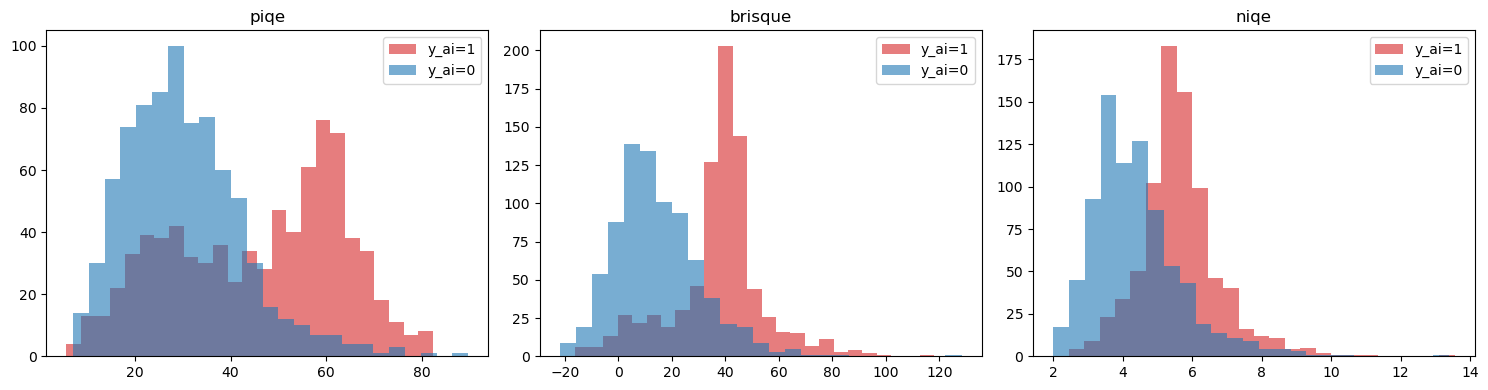

In [8]:
plot_cols = ["piqe", "brisque", "niqe"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, plot_cols):
    for label, color in [(1, "tab:red"), (0, "tab:blue")]:
        ax.hist(data[data["y_ai"] == label][col], bins=25, alpha=0.6, label=f"y_ai={label}", color=color)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

## 5. Split 80:20 dengan stratifikasi gabungan

In [9]:
X = data[feature_cols].to_numpy(dtype=np.float32)
y = data["y_ai"].to_numpy(dtype=np.int64)
stratify_key = data["generator"].astype(str) + "|" + data["y_ai"].astype(str) + "|" + data["content_label"].astype(str)

X_train, X_eval, y_train, y_eval, train_idx, eval_idx = train_test_split(
    X, y, data.index.to_numpy(), test_size=0.2, random_state=42, stratify=stratify_key
)

print("Train:", X_train.shape, y_train.shape)
print("Eval:", X_eval.shape, y_eval.shape)

Train: (1280, 67) (1280,)
Eval: (320, 67) (320,)


## 6. Train baseline

In [10]:
MLP_HIDDEN = (128, 64)
models = {
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42,
    ),
    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(hidden_layer_sizes=MLP_HIDDEN, activation="relu", max_iter=500, random_state=42)),
    ]),
}

results = []
pred_store = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    score_ai = model.predict_proba(X_eval)[:, 1]
    pred_ai = (score_ai >= 0.5).astype(np.int64)
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_eval, pred_ai),
        "f1": f1_score(y_eval, pred_ai),
        "auroc": roc_auc_score(y_eval, score_ai),
    })
    pred_store[name] = {"score_ai": score_ai, "pred_ai": pred_ai}

results_df = pd.DataFrame(results).sort_values(by=["auroc", "f1", "accuracy"], ascending=False).reset_index(drop=True)
display(results_df)

,model,accuracy,f1,auroc
0,MLP,0.968750,0.968750,0.996836
1,XGBoost,0.946875,0.947692,0.989297


## 7. Confusion matrix model terbaik

Best model: MLP

              precision    recall  f1-score   support

      nature       0.97      0.97      0.97       160
          ai       0.97      0.97      0.97       160

    accuracy                           0.97       320
   macro avg       0.97      0.97      0.97       320
weighted avg       0.97      0.97      0.97       320



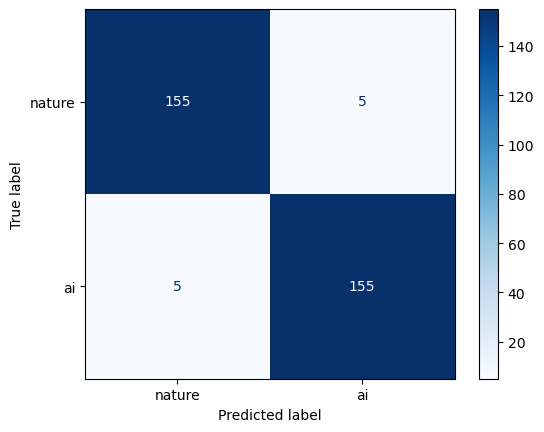

In [11]:
best_model = results_df.iloc[0]["model"]
print("Best model:", best_model)
print()
print(classification_report(y_eval, pred_store[best_model]["pred_ai"], target_names=["nature", "ai"]))
cm = confusion_matrix(y_eval, pred_store[best_model]["pred_ai"])
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["nature", "ai"]).plot(cmap="Blues")
plt.show()

## 8. Simpan hasil

In [12]:
metrics_df = results_df.copy()
metrics_df["feature_set"] = "iqa_plus_clip"
metrics_df["iqa_metrics"] = "piqe,brisque,niqe"
metrics_df["clip_model"] = CLIP_MODEL_NAME
metrics_df["clip_out_dim"] = CLIP_OUT_DIM
metrics_df["split_protocol"] = "train_holdout_80_20_stratified_generator_label_class"
metrics_df["subset_name"] = SUBSET_NAME
metrics_df["n_total"] = len(data)
metrics_df["n_train"] = len(X_train)
metrics_df["n_eval"] = len(X_eval)
metrics_df.to_csv(METRICS_OUT, index=False)

base_eval = data.iloc[eval_idx][["image_id", "path", "generator", "class_name", "content_id", "content_label", "y_ai"]].copy()
pred_parts = []
for name, pred in pred_store.items():
    part = base_eval.copy()
    part["model"] = name
    part["score_ai"] = pred["score_ai"]
    part["pred_ai"] = pred["pred_ai"]
    pred_parts.append(part)

pred_df = pd.concat(pred_parts, ignore_index=True)
pred_df.to_csv(PRED_OUT, index=False)

print("Saved metrics:", METRICS_OUT.resolve())
print("Saved predictions:", PRED_OUT.resolve())
display(metrics_df)
display(pred_df.head())

Saved metrics: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/results_classification_biggan_midjourney_cat4_iqa_clip.csv
Saved predictions: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/predictions_classification_biggan_midjourney_cat4_iqa_clip.csv


,model,accuracy,f1,auroc,feature_set,iqa_metrics,clip_model,clip_out_dim,split_protocol,subset_name,n_total,n_train,n_eval
0,MLP,0.968750,0.968750,0.996836,iqa_plus_clip,"piqe,brisque,niqe",openai/clip-vit-base-patch32,64,train_holdout_80_20_stratified_generator_label...,biggan_midjourney_cat4_train,1600,1280,320
1,XGBoost,0.946875,0.947692,0.989297,iqa_plus_clip,"piqe,brisque,niqe",openai/clip-vit-base-patch32,64,train_holdout_80_20_stratified_generator_label...,biggan_midjourney_cat4_train,1600,1280,320


,image_id,path,generator,class_name,content_id,content_label,y_ai,model,score_ai,pred_ai
0,img_5c0122de7d444ac7,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,MidJourney,ai,284,Siamese_cat,1,XGBoost,0.652559,1
1,img_12676a251329560c,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN,nature,n02124075,Egyptian_cat,0,XGBoost,0.003355,0
2,img_b971b0a094f3adc7,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN,nature,n02123597,Siamese_cat,0,XGBoost,0.056908,0
3,img_7b7da66f2ea0c42c,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN,nature,n02123045,tabby,0,XGBoost,0.025207,0
4,img_83952d8544536cd5,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN,ai,284,Siamese_cat,1,XGBoost,0.889856,1


## 9. Catatan interpretasi

Notebook ini menguji apakah metrik IQA tradisional masih memberi nilai tambah saat digabung dengan sinyal semantik dari CLIP.